In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)

matches = pd.read_csv('data/cleaned_matches.csv')
deliveries = pd.read_csv('data/cleaned_deliveries.csv')


In [2]:
team1 = matches['team1'].value_counts()

team2 = matches['team2'].value_counts()

matches_played = team1.add(team2, fill_value=0)

In [3]:
wins = matches['winner'].value_counts()

In [7]:
team_stats = pd.DataFrame({
    'matches_played': matches_played,
    'wins': wins
}).fillna(0)
team_stats = team_stats[
    team_stats['matches_played'] > 0
]
team_stats['win_percentage'] = (
    team_stats['wins']
    / team_stats['matches_played']
) * 100

team_stats.sort_values(
    'win_percentage',
    ascending=False
).head(10)

,matches_played,wins,win_percentage
Rising Pune Supergiant,16.0,10,62.500000
Gujarat Titans,45.0,28,62.222222
Chennai Super Kings,238.0,138,57.983193
Mumbai Indians,261.0,144,55.172414
Lucknow Super Giants,44.0,24,54.545455
Kolkata Knight Riders,251.0,131,52.191235
Rajasthan Royals,221.0,112,50.678733
Sunrisers Hyderabad,182.0,88,48.351648
Royal Challengers Bangalore,240.0,116,48.333333
Royal Challengers Bengaluru,15.0,7,46.666667


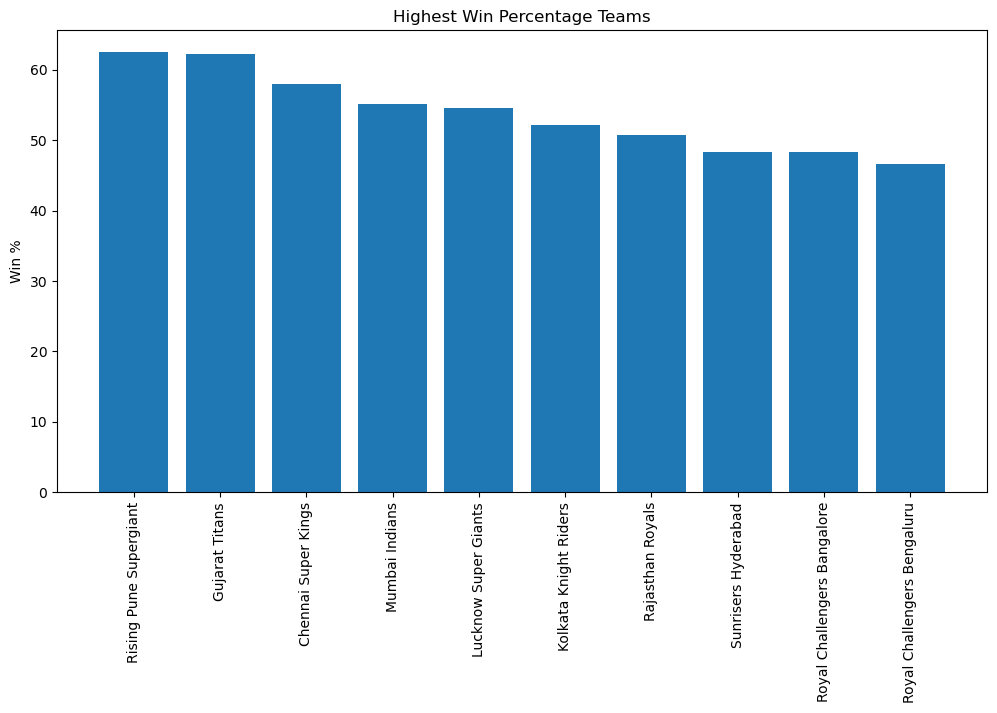

In [8]:
top_win_pct = team_stats.sort_values(
    'win_percentage',
    ascending=False
).head(10)

plt.bar(
    top_win_pct.index,
    top_win_pct['win_percentage']
)

plt.xticks(rotation=90)
plt.ylabel("Win %")
plt.title("Highest Win Percentage Teams")
plt.show()

### Toss Impact Analysis ###

In [9]:
matches['toss_match_win'] = (
    matches['toss_winner']
    == matches['winner']
)

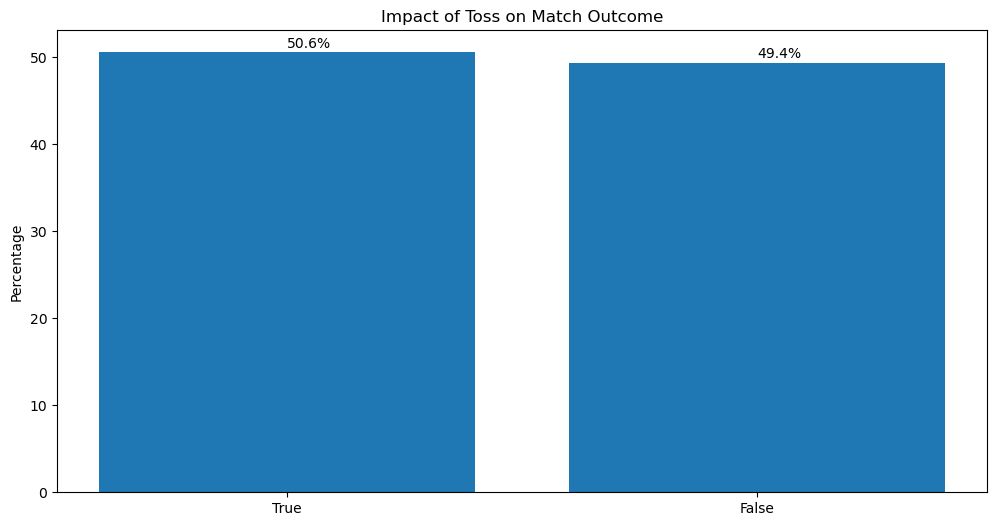

In [11]:
toss_counts = (
    matches['toss_match_win']
    .value_counts(normalize=True)
    * 100
)

plt.bar(
    toss_counts.index.astype(str),
    toss_counts.values
)

plt.ylabel("Percentage")

plt.title("Impact of Toss on Match Outcome")

for i, v in enumerate(toss_counts.values):
    plt.text(i, v+0.5, f"{v:.1f}%")

plt.show()

### Insights

- Teams that won the toss also won the match in approximately **50.7%** of IPL matches.
- Teams that lost the toss still won **49.3%** of matches.
- The difference between the two outcomes is minimal, indicating that toss advantage alone is not a major determinant of match success.
- Team quality, match conditions, batting performance, and bowling execution appear to have a greater impact on match outcomes than toss results.
- These findings suggest that the commonly perceived importance of winning the toss may be overstated when viewed across the entire history of the IPL.

### Best Chasing Teams

In [12]:
chasing_wins = matches[
    matches['result'] == 'wickets'
]

In [15]:
chase_wins = (
    chasing_wins['winner']
    .value_counts()
)

In [16]:
team2_matches = (
    matches['team2']
    .value_counts()
)

In [17]:
chase_stats = pd.DataFrame({
    'chase_matches': team2_matches,
    'chase_wins': chase_wins
}).fillna(0)

In [18]:
chase_stats['chase_success_rate'] = (
    chase_stats['chase_wins']
    / chase_stats['chase_matches']
) * 100

In [19]:
chase_stats = chase_stats[
    chase_stats['chase_matches'] >= 30
]

In [20]:
chase_stats = chase_stats.sort_values(
    'chase_success_rate',
    ascending=False
)

chase_stats.head(10)

,chase_matches,chase_wins,chase_success_rate
Chennai Super Kings,110,67,60.909091
Kolkata Knight Riders,130,76,58.461538
Royal Challengers Bangalore,105,61,58.095238
Rajasthan Royals,120,67,55.833333
Delhi Capitals,126,66,52.380952
Mumbai Indians,138,71,51.449275
Punjab Kings,123,58,47.154472
Sunrisers Hyderabad,96,43,44.791667
Deccan Chargers,36,11,30.555556


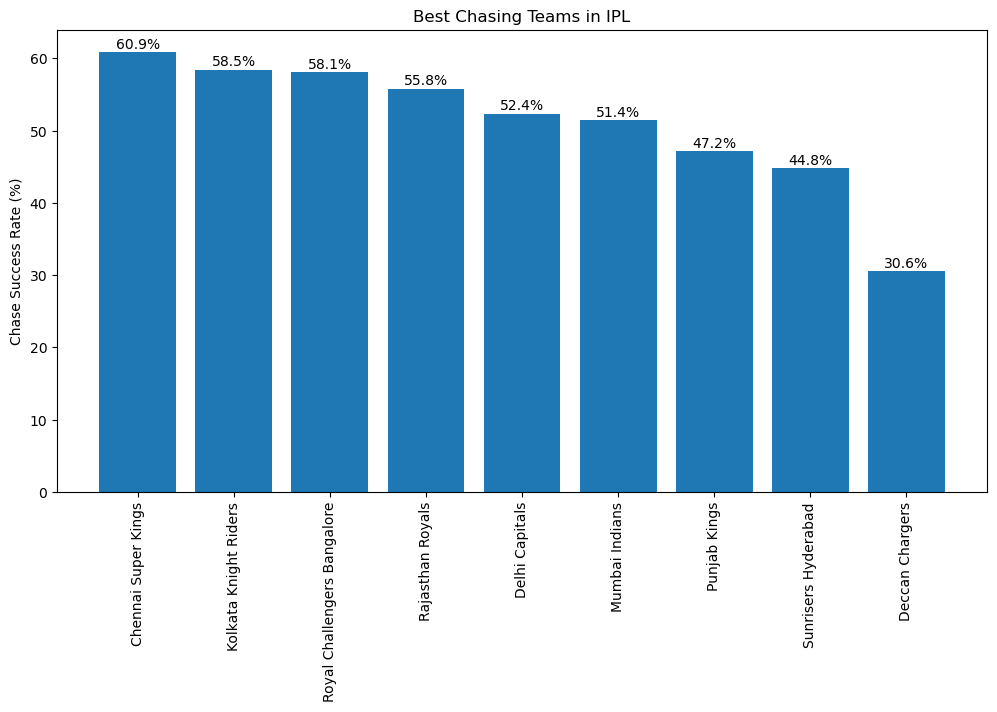

In [23]:
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_chasers.index,
    top_chasers['chase_success_rate']
)

plt.xticks(rotation=90)

plt.ylabel("Chase Success Rate (%)")

plt.title("Best Chasing Teams in IPL")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center'
    )

plt.show()

### Insights

- Chennai Super Kings emerged as the most effective chasing side in IPL history, successfully winning approximately 61% of matches when batting second.
- Kolkata Knight Riders and Royal Challengers Bangalore also demonstrated strong chasing capabilities, with success rates exceeding 58%.
- Rajasthan Royals maintained a chase success rate above 55%, indicating consistent performance under scoreboard pressure.
- Mumbai Indians, despite being the most successful franchise overall, achieved a comparatively modest chase success rate of approximately 52%, suggesting that a significant portion of their success was built on balanced performance across both innings.
- Punjab Kings and Sunrisers Hyderabad recorded chase success rates below 50%, indicating greater difficulty converting run chases into victories.
- Deccan Chargers displayed the lowest chase efficiency among the analyzed teams, with a success rate of approximately 31%.

### Cricket Interpretation

- High chase success rates often indicate strong middle-order stability, effective finishing ability, and adaptability to changing match situations.
- Teams consistently successful while chasing are generally more comfortable operating under target-driven pressure.
- Chase efficiency provides a more reliable measure of batting depth than total chase victories because it accounts for differences in matches played.

### Best Defending Teams

In [24]:
# Teams batting first
bat_first = matches['team1'].value_counts()

# Matches won by defending
defending_wins = matches[
    matches['result'] == 'runs'
]['winner'].value_counts()

defense_stats = pd.DataFrame({
    'bat_first_matches': bat_first,
    'successful_defenses': defending_wins
}).fillna(0)

defense_stats['defense_success_rate'] = (
    defense_stats['successful_defenses']
    / defense_stats['bat_first_matches']
) * 100

defense_stats = defense_stats[
    defense_stats['bat_first_matches'] >= 30
]

defense_stats = defense_stats.sort_values(
    'defense_success_rate',
    ascending=False
)

defense_stats.head(10)

,bat_first_matches,successful_defenses,defense_success_rate
Mumbai Indians,123,71,57.723577
Chennai Super Kings,128,71,55.468750
Sunrisers Hyderabad,86,44,51.162791
Deccan Chargers,39,18,46.153846
Kolkata Knight Riders,121,54,44.628099
Rajasthan Royals,101,43,42.574257
Punjab Kings,123,51,41.463415
Royal Challengers Bangalore,135,53,39.259259
Delhi Capitals,126,46,36.507937


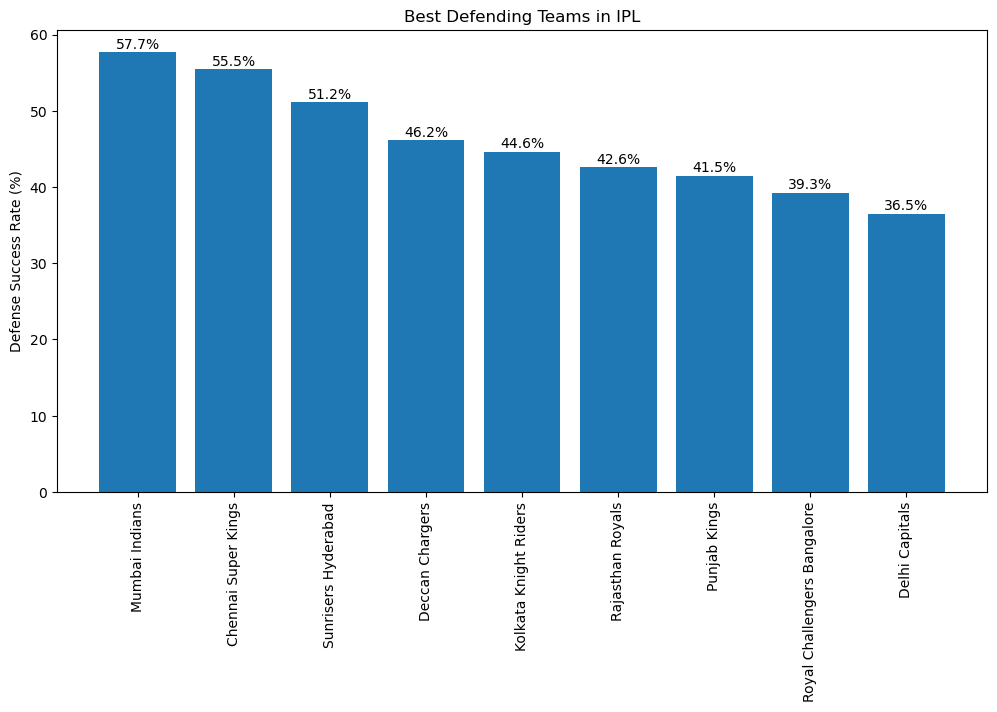

In [25]:
top_defenders = defense_stats.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(
    top_defenders.index,
    top_defenders['defense_success_rate']
)

plt.xticks(rotation=90)

plt.ylabel("Defense Success Rate (%)")

plt.title("Best Defending Teams in IPL")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.5,
        f"{h:.1f}%",
        ha='center'
    )

plt.show()

### Team Performance by Season

In [26]:
season_team_wins = (
    matches.groupby(
        ['season_year','winner']
    )
    .size()
    .reset_index(name='wins')
)

top_team_each_season = (
    season_team_wins
    .sort_values(
        ['season_year','wins'],
        ascending=[True,False]
    )
    .groupby('season_year')
    .head(1)
)

top_team_each_season

,season_year,winner,wins
6,2008,Rajasthan Royals,13
10,2009,Delhi Capitals,10
20,2010,Mumbai Indians,11
24,2011,Chennai Super Kings,11
38,2012,Kolkata Knight Riders,12
47,2013,Mumbai Indians,13
57,2014,Punjab Kings,12
61,2015,Chennai Super Kings,10
77,2016,Sunrisers Hyderabad,11
81,2017,Mumbai Indians,12


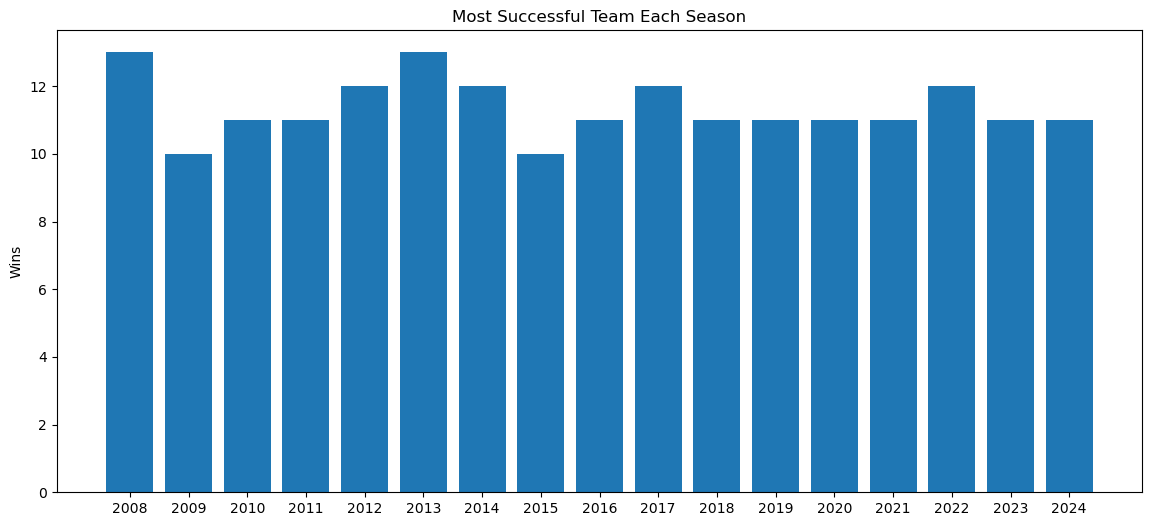

In [27]:
plt.figure(figsize=(14,6))

plt.bar(
    top_team_each_season['season_year'].astype(str),
    top_team_each_season['wins']
)

plt.title(
    "Most Successful Team Each Season"
)

plt.ylabel("Wins")

plt.show()

### Head-to-Head Analysis

In [28]:
h2h = matches.groupby(
    ['team1', 'team2', 'winner']
).size().reset_index(name='wins')

h2h.head()

,team1,team2,winner,wins
0,Chennai Super Kings,Deccan Chargers,Chennai Super Kings,4
1,Chennai Super Kings,Deccan Chargers,Deccan Chargers,3
2,Chennai Super Kings,Delhi Capitals,Chennai Super Kings,11
3,Chennai Super Kings,Delhi Capitals,Delhi Capitals,6
4,Chennai Super Kings,Gujarat Titans,Chennai Super Kings,2


In [29]:
def head_to_head(team_a, team_b):

    rivalry = matches[
        (
            (matches['team1'] == team_a)
            &
            (matches['team2'] == team_b)
        )
        |
        (
            (matches['team1'] == team_b)
            &
            (matches['team2'] == team_a)
        )
    ]

    return rivalry['winner'].value_counts()

In [30]:
teams = sorted(
    list(
        set(matches['team1'])
    )
)

h2h_matrix = pd.DataFrame(
    index=teams,
    columns=teams
)

In [31]:
for team1 in teams:

    for team2 in teams:

        if team1 == team2:
            h2h_matrix.loc[team1, team2] = '-'

        else:

            rivalry = matches[
                (
                    (matches['team1'] == team1)
                    &
                    (matches['team2'] == team2)
                )
                |
                (
                    (matches['team1'] == team2)
                    &
                    (matches['team2'] == team1)
                )
            ]

            wins = (
                rivalry['winner']
                .value_counts()
            )

            team1_wins = wins.get(team1, 0)

            h2h_matrix.loc[
                team1,
                team2
            ] = team1_wins

In [32]:
h2h_matrix

,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Gujarat Lions,Gujarat Titans,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Royal Challengers Bengaluru,Sunrisers Hyderabad
Chennai Super Kings,-,6,19,0,3,1,19,1,17,4,16,16,0,0,20,1,15
Deccan Chargers,4,-,4,0,0,1,2,0,4,3,3,2,0,0,6,0,0
Delhi Capitals,11,7,-,3,3,1,15,2,16,3,16,14,2,0,11,0,11
Gujarat Lions,0,0,1,-,0,0,3,0,2,0,2,0,1,2,2,0,0
Gujarat Titans,4,0,2,0,-,0,2,4,3,0,3,5,0,0,2,0,3
Kochi Tuskers Kerala,1,0,1,0,0,-,2,0,1,0,0,1,0,0,0,0,0
Kolkata Knight Riders,10,7,18,1,1,0,-,2,11,4,21,14,1,2,18,2,19
Lucknow Super Giants,3,0,3,0,1,0,3,-,5,0,3,1,0,0,1,1,3
Mumbai Indians,20,6,19,2,2,0,23,1,-,5,17,15,1,1,18,1,13
Pune Warriors,2,1,2,0,0,1,1,0,1,-,3,1,0,0,0,0,0


### each team's biggest rival

In [33]:
rivalries = []

for team in teams:

    team_matches = matches[
        (matches['team1'] == team)
        |
        (matches['team2'] == team)
    ]

    opponents = []

    for opp in teams:

        if opp != team:

            rivalry = team_matches[
                (
                    (team_matches['team1'] == opp)
                    |
                    (team_matches['team2'] == opp)
                )
            ]

            opponents.append(
                (opp, len(rivalry))
            )

    biggest_rival = max(
        opponents,
        key=lambda x: x[1]
    )

    rivalries.append(
        [team,
         biggest_rival[0],
         biggest_rival[1]]
    )

rivalries_df = pd.DataFrame(
    rivalries,
    columns=[
        'Team',
        'Biggest Rival',
        'Matches'
    ]
)

rivalries_df

,Team,Biggest Rival,Matches
0,Chennai Super Kings,Mumbai Indians,37
1,Deccan Chargers,Delhi Capitals,11
2,Delhi Capitals,Mumbai Indians,35
3,Gujarat Lions,Royal Challengers Bangalore,5
4,Gujarat Titans,Chennai Super Kings,7
5,Kochi Tuskers Kerala,Chennai Super Kings,2
6,Kolkata Knight Riders,Mumbai Indians,34
7,Lucknow Super Giants,Mumbai Indians,6
8,Mumbai Indians,Chennai Super Kings,37
9,Pune Warriors,Chennai Super Kings,6


### Insights

- The most prominent rivalry in IPL history is between Chennai Super Kings and Mumbai Indians, who have faced each other **37 times**, making it the most frequently contested matchup in the dataset.

- Mumbai Indians emerge as the biggest rival for multiple franchises, including Chennai Super Kings, Delhi Capitals, Kolkata Knight Riders, Lucknow Super Giants, and Rising Pune Supergiant. This reflects Mumbai Indians' long-term presence and competitiveness within the league.

- Chennai Super Kings also appear frequently as the primary rival for several teams, including Rajasthan Royals, Gujarat Titans, Pune Warriors, Kochi Tuskers Kerala, and Royal Challengers Bengaluru, highlighting their consistent participation and success across IPL seasons.

- Established franchises tend to have rivalry counts exceeding **30 matches**, while newer teams such as Gujarat Titans and Lucknow Super Giants naturally show lower rivalry frequencies due to fewer seasons played.

- The Chennai Super Kings–Mumbai Indians rivalry stands out as the defining matchup of the IPL era, with both teams ranking among the most successful franchises in league history.

- Rivalry frequency is strongly associated with franchise longevity. Teams that have participated in the IPL for a longer period naturally develop deeper competitive histories with other established franchises.

### Cricket Interpretation

- Frequent rivalries often emerge between successful franchises that consistently qualify for playoffs and encounter each other in high-pressure matches.

- Rivalry analysis highlights recurring competitive matchups that shape league narratives and fan engagement.

- Understanding opponent-specific histories provides context beyond overall win percentages and helps identify long-term competitive relationships between franchises.

### Key Takeaway

The IPL's rivalry landscape is dominated by long-standing franchises, particularly Mumbai Indians and Chennai Super Kings. Their repeated encounters against multiple teams demonstrate not only longevity but also sustained competitiveness, making them central figures in the league's historical narrative.

# Conclusion

This notebook analyzed IPL team performance across multiple dimensions, including overall win percentage, toss influence, chasing efficiency, defending efficiency, seasonal dominance, and head-to-head rivalries.

## Key Findings

### Team Performance

Win percentage analysis revealed that overall franchise success cannot be evaluated solely through total victories. Teams with strong win percentages demonstrated sustained competitiveness and consistency across multiple seasons.

### Toss Impact

The analysis showed that winning the toss had a limited impact on match outcomes. Teams that won the toss won approximately 50.7% of matches, while teams that lost the toss still won 49.3% of matches. This suggests that team quality and match execution are significantly more important than toss outcomes.

### Chasing Performance

Chase success rate analysis identified clear differences in teams' ability to perform under scoreboard pressure. Chennai Super Kings emerged as the most efficient chasing side, successfully converting more than 60% of their chase opportunities into victories.

### Defending Performance

Defending efficiency highlighted the importance of bowling strength and game management. Teams with high defense success rates consistently protected first-innings totals through disciplined bowling and effective death-over execution.

### Seasonal Dominance

Seasonal analysis demonstrated that IPL dominance occurs in cycles, with different franchises controlling different eras of the tournament. Sustained success was strongly associated with squad stability, leadership continuity, and effective team management.

### Rivalry Analysis

Head-to-head analysis revealed that the Chennai Super Kings–Mumbai Indians rivalry remains the most significant matchup in IPL history, with 37 encounters recorded in the dataset. Rivalries provided insights that were not visible through overall league performance alone.

## Overall Takeaway

The analysis demonstrates that successful IPL franchises combine multiple strengths rather than relying on a single factor. Teams that consistently perform well while chasing, defending, and maintaining strong seasonal records tend to achieve long-term success.

The findings from this notebook establish a strong foundation for player-level performance analysis, where individual contributions behind team success will be investigated in the next stage of the project.